In [1]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
os.environ["MKL_CBWR"] = "COMPATIBLE"
os.environ["ATEN_CPU_CAPABILITY"] = "avx2"
os.environ["OMP_NUM_THREADS"] = os.environ["MKL_NUM_THREADS"] = os.environ["OPENBLAS_NUM_THREADS"] = "8"
os.environ["NPY_DISABLE_CPU_FEATURES"] = "AVX512F AVX512CD AVX512_KNL AVX512_KNM AVX512_SKX AVX512_CLX AVX512_CNL AVX512_ICL AVX512_SPR"
os.environ["OPENBLAS_CORETYPE"] = "Haswell"
# JAX (GW solves) and PyTorch (φ/ψ training) share the GPU. Stop JAX from reserving
# most of the card upfront; it allocates as needed, up to 95% for the final GW solve.
# Must be set before JAX is imported.
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

import sys
sys.path.append("..")

# Example Alignment on Human Embryo Slices (HESTA)

We align two Stereo-seq sagittal sections of human embryos from HESTA, the Human Embryogenesis Spatiotemporal Transcriptomic Atlas (https://db.cngb.org/hesta/download/).

The available slices are `CS17_E1S8`, `CS17_E1S9` (Carnegie stage 17) and `CS18_E1S3`, `CS18_E1S4` (Carnegie stage 18), each stored as `<slice>_HESTA.h5ad`. **Pick the two slices to compare in the next cell.** The same cell sets `HESTA_DIR`, the folder with the downloaded files. Leave it as `None` to use the `hesta/` subfolder of the MGW data directory (from `get_data_dir()`, as in `mouse_align.ipynb`). Two slices from the same stage give an adjacent-section alignment. A CS17 and a CS18 slice give a spatiotemporal alignment.

The pipeline is the same as `mouse_align.ipynb`: no fused FGW feature information is used, so the alignment treats the data as if it were "multimodal."

In [2]:
# ============================================================
# Choose the two slices to align
# ============================================================
HESTA_SLICES = ["CS17_E1S8", "CS17_E1S9", "CS18_E1S3", "CS18_E1S4"]

SLICE_A = "CS17_E1S9"   # source slice
SLICE_B = "CS18_E1S4"   # target slice

assert SLICE_A in HESTA_SLICES and SLICE_B in HESTA_SLICES, f"choose from {HESTA_SLICES}"
assert SLICE_A != SLICE_B, "choose two different slices"

# Folder holding the <slice>_HESTA.h5ad files (None: <MGW data dir>/hesta)
HESTA_DIR = None   # e.g. "/path/to/hesta_downloads"

In [3]:
# ============================================================
# M-GW: Pairwise Alignment of Human Embryo (HESTA) Slices
# ============================================================

import scanpy as sc
import anndata as ad
import numpy as np, torch, scipy.sparse as sp
from mgw import util, models, plotting, geometry
from mgw import pullback_metric_field, knn_graph
from mgw.gw import solve_gw_ott
import importlib
import matplotlib.pyplot as plt
import os
from mgw.config import get_data_dir

# ----------------------------
# Runtime & device setup
# ----------------------------
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_default_dtype(torch.float64)
print("Device:", device)

# ----------------------------
# Input files & parameters
# ----------------------------
from pathlib import Path

if HESTA_DIR is None:
    HESTA_DIR = get_data_dir() / 'hesta'  # asks on first run, then remembered per machine
HESTA_DIR = Path(HESTA_DIR).expanduser()
print("HESTA data directory:", HESTA_DIR)

slice_ids = [SLICE_A, SLICE_B]
filehandles_hesta_adata = [HESTA_DIR / f"{s}_HESTA.h5ad" for s in slice_ids]
for fh in filehandles_hesta_adata:
    if not fh.exists():
        raise FileNotFoundError(f"{fh} not found. Set HESTA_DIR above, or call "
                                "get_data_dir(reset=True) to change the data directory.")

# Embedding / network parameters
PCA_comp   = 30
knn_k      = 12
geodesic_eps = 0.01

# Whole-embryo sections hold 65k-130k bins, and the GW solve keeps several n x n matrices
# on the GPU (float32: ~0.73 GiB each at 14k bins, ~1.5 GiB at 20k). 20k runs out of
# memory on a 16 GB GPU; lower this further if needed. None keeps every bin.
MAX_OBS = 14_000

gw_params = dict(verbose=True, inner_maxit=3000, outer_maxit=3000,
                 inner_tol=1e-7, outer_tol=1e-7, epsilon=1e-4)

save_dir = HESTA_DIR / "alignments"
os.makedirs(save_dir, exist_ok=True)

# ============================================================
# 1. Load datasets and prepare
# ============================================================
def load_hesta_slice(fh, slice_id):
    adata = sc.read_h5ad(fh)

    # X is log-normalized; raw counts are in layers['counts']. Keep only the counts:
    # concat would otherwise copy both matrices.
    adata.X = adata.layers.pop('counts')
    # Coordinates are stored as uint32; cast so differences don't wrap around
    adata.obsm['spatial'] = adata.obsm['spatial'].astype(np.float64)

    adata.obs['slice'] = [slice_id] * adata.shape[0]
    adata.obs_names = [f"{slice_id}_{n}" for n in adata.obs_names]
    print(f"[{slice_id}] {fh.name}: {adata.n_obs} bins x {adata.n_vars} genes")
    return adata

print('Loading AnnData slices...')
adatas = [load_hesta_slice(fh, s) for fh, s in zip(filehandles_hesta_adata, slice_ids)]

# Intersect genes across all slices
common_genes = sorted(set.intersection(*[set(a.var_names) for a in adatas]))
adatas = [a[:, common_genes] for a in adatas]
print(f"Common genes: {len(common_genes)}")

Device: cuda
HESTA data directory: /nas/lnt/ga79jin/MGW/data/hesta
Loading AnnData slices...
[CS17_E1S9] CS17_E1S9_HESTA.h5ad: 65607 bins x 46144 genes
[CS18_E1S4] CS18_E1S4_HESTA.h5ad: 152371 bins x 46814 genes
Common genes: 43595


In [4]:
from mgw import metrics
from mgw import mgw as mgw
from scipy.spatial.distance import cdist

ad1, ad2 = adatas[0], adatas[1]
tp1, tp2 = slice_ids[0], slice_ids[1]

print(f"\n--- Aligning {tp1} → {tp2} ---")

# Normalization, log1p, PCA
joint = ad.concat([ad1, ad2], join='inner')

# Free the per-slice copies before normalization and PCA allocate more
import gc
del adatas, ad1, ad2
gc.collect()

sc.pp.normalize_total(joint)
sc.pp.log1p(joint)
sc.pp.pca(joint, n_comps=PCA_comp)

# Split back into slices, copying only the MAX_OBS bins mgw_preprocess keeps (same bins:
# both draw them with seed 42). Copying whole slices can exhaust the server's RAM.
def split_slice(slice_id):
    view = joint[joint.obs['slice'] == slice_id]
    return util.downsample_per_slice(view, MAX_OBS) if MAX_OBS else view.copy()

A, B = split_slice(tp1), split_slice(tp2)
del joint
gc.collect()

# ========================================================
# (a) Feature preprocessing (PCA + CCA "feeler")
# ========================================================

pre = mgw.mgw_preprocess(
        A, B,
        PCA_comp=10,
        CCA_comp=3,
        use_cca_feeler=False,
        use_pca_X=True,
        use_pca_Z=True,
        log1p_X=True,
        log1p_Z=True,
        max_obs_A=MAX_OBS,
        max_obs_B=MAX_OBS,
        verbose=True,
        feature_only=False,
        spatial_only=True,
        rep_norm="zscore",
)

# Keep the (possibly subsampled) slices so they match the coupling
A, B = pre["A_"], pre["B_"]
print(f"Bins used: {tp1}={A.n_obs}, {tp2}={B.n_obs}")


--- Aligning CS17_E1S9 → CS18_E1S4 ---
[mgw.pre] PCA/raw shapes: X=(14000, 10)  Z=(14000, 10)
Bins used: CS17_E1S9=14000, CS18_E1S4=14000


# Check the CCA feeler alignment.

The CCA is fit on pairs from a small spatial-only GW between random subsets of the two slices. If that coupling is mirrored or diffuse, the SM features are fit to the wrong partners. The plot draws B in the frame the feeler coupling implies (reflection allowed). The orientation check fits a rotation and a reflection to it. The row entropy measures how spread out it is.

In [5]:
from matplotlib.collections import LineCollection
from mgw import align_vis

def plot_coupling_lines(xa, xb, P, name, n_lines=1500, seed=0):
    """Draw B in the frame the coupling implies (reflection allowed); join random A bins to their peak B target."""
    P = np.asarray(P)
    xb_aligned, _, _, _, _ = align_vis.coupling_procrustes(xa, xb, P, ensure_rotation=False)
    idx = np.random.default_rng(seed).choice(len(xa), min(len(xa), n_lines), replace=False)
    jdx = P[idx].argmax(1)
    shift = np.array([xa[:, 0].max() - xb_aligned[:, 0].min() + 0.3 * np.ptp(xa[:, 0]), 0.0])

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.scatter(*xa.T, s=1, c="C0", label=tp1)
    ax.scatter(*(xb_aligned + shift).T, s=1, c="C1", label=f"{tp2} (coupling frame)")
    ax.add_collection(LineCollection(np.stack([xa[idx], xb_aligned[jdx] + shift], axis=1),
                                     colors="k", alpha=0.08, lw=0.5))
    ax.set_title(f"{name}: peak target of {len(idx):,} random {tp1} bins")
    ax.set_aspect("equal"); ax.axis("off")
    ax.legend(markerscale=8, frameon=False)
    plt.show()
    return xb_aligned

def orientation_report(xa, xb, P):
    """Rigid fit of A onto its barycentric image in B, as a rotation and as a reflection."""
    P = np.asarray(P)
    Y = (P @ xb.astype(P.dtype)) / P.sum(1, keepdims=True)
    Xc, Yc = xa - xa.mean(0), Y - Y.mean(0)
    U, _, Vt = np.linalg.svd(Xc.T @ Yc)
    d = np.sign(np.linalg.det(U @ Vt))
    print(f"orientation det = {d:+.0f}")
    for kind, Q in [("rotation", U @ np.diag([1, d]) @ Vt), ("reflection", U @ np.diag([1, -d]) @ Vt)]:
        rms = np.sqrt(((Xc @ Q - Yc) ** 2).sum(1).mean())
        angle = np.degrees(np.arctan2(Q[0, 1], Q[0, 0]))
        what = f"angle {angle:+4.0f}°" if kind == "rotation" else f"mirror axis {angle / 2:+4.0f}°"
        print(f"best {kind:<10}  {what}  rms {rms:.4f}")

def row_entropy(p):
    p = p / p.sum()
    return -(p * np.log(p + 1e-30)).sum()

feeler = pre["feeler"]
if feeler is None:
    print("No CCA feeler was computed (use_cca_feeler=False).")
else: 
    xa_feeler = feeler["xs"][feeler["meta"]["idxX_feeler"]]
    xb_feeler = feeler["xt"][feeler["meta"]["idxZ_feeler"]]
    P_feeler = np.asarray(feeler["P_feeler"])

    _ = plot_coupling_lines(xa_feeler, xb_feeler, P_feeler, "CCA feeler coupling")
    orientation_report(xa_feeler, xb_feeler, P_feeler)
    H = np.mean([row_entropy(p) for p in P_feeler])
    print(f"mean row entropy {H:.2f}  (uniform {np.log(P_feeler.shape[1]):.2f}, one-to-one 0)")

No CCA feeler was computed (use_cca_feeler=False).


In [6]:
PCA_component = 30
CCA_component = 3

PHI_ARC = (128,256,256,128)
KNN_K= 12
DEFAULT_GW_PARAMS = dict(verbose=True, inner_maxit=3000, outer_maxit=3000, inner_tol=1e-7,   outer_tol=1e-7,   epsilon=1e-4)
DEFAULT_LR = 1e-3
DEFAULT_EPS = 1e0
DEFAULT_ITER = 20_000
SEED = 1

In [7]:
EXP_PATH = None #specify the path to save your trained phi psi model (None: retrain without caching)
EXP_TAG = f'HESTA_{SLICE_A}_{SLICE_B}_CCA_seed{SEED}' #specify the name of your experiment

[mgw.core] device=cuda dtype=torch.float64
[mgw.core] dims: E=2, F_M=10, F_N=10
[mgw.core] seed=1
[mgw.core] deterministic training (fused Adam, deterministic kernels)
[mgw.core] training φ, ψ
[train_phi] step=1000 loss=0.610039
[train_phi] step=2000 loss=0.562049
[train_phi] step=3000 loss=0.515225
[train_phi] step=4000 loss=0.506236
[train_phi] step=5000 loss=0.480914
[train_phi] step=6000 loss=0.481857
[train_phi] step=7000 loss=0.465245
[train_phi] step=8000 loss=0.452471
[train_phi] step=9000 loss=0.507135
[train_phi] step=10000 loss=0.452875
[train_phi] step=11000 loss=0.430770
[train_phi] step=12000 loss=0.448415
[train_phi] step=13000 loss=0.419250
[train_phi] step=14000 loss=0.419833
[train_phi] step=15000 loss=0.433022
[train_phi] step=16000 loss=0.413235
[train_phi] step=17000 loss=0.403521
[train_phi] step=18000 loss=0.401877
[train_phi] step=19000 loss=0.420369
[train_phi] step=20000 loss=0.403881
[train_phi] step=1000 loss=0.661588
[train_phi] step=2000 loss=0.557360
[tra

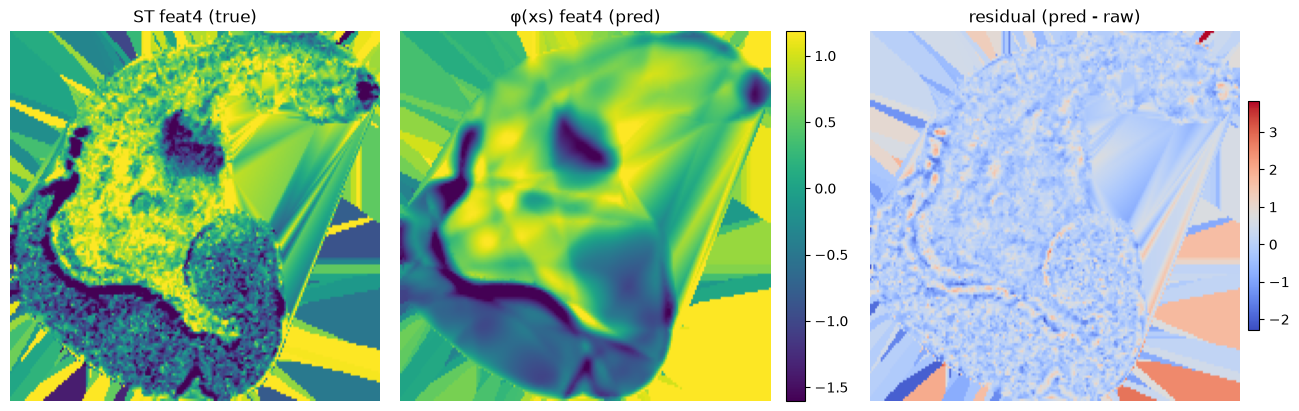

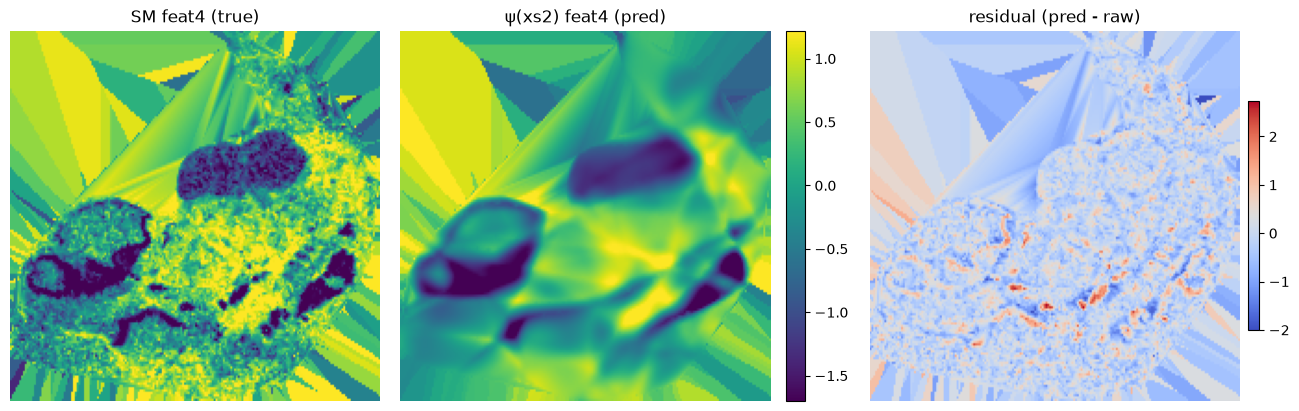

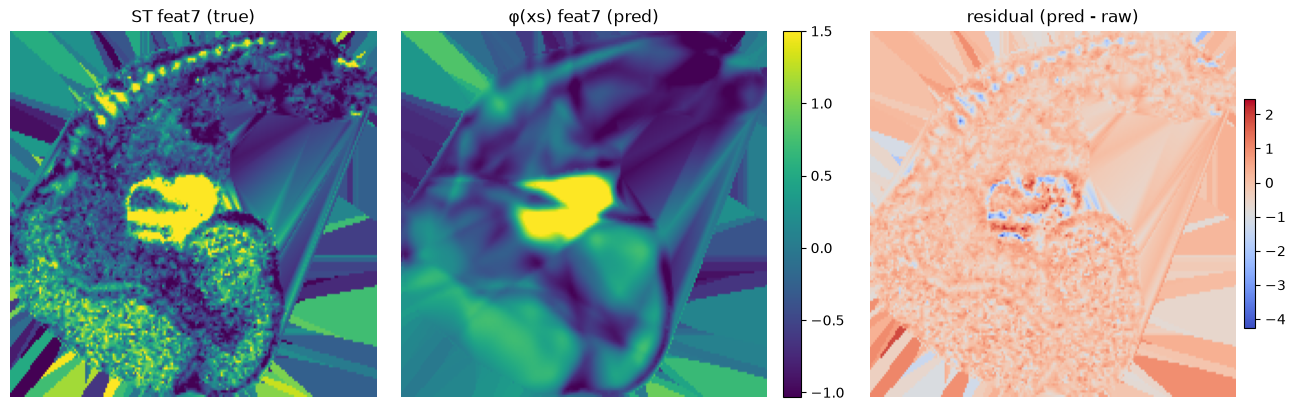

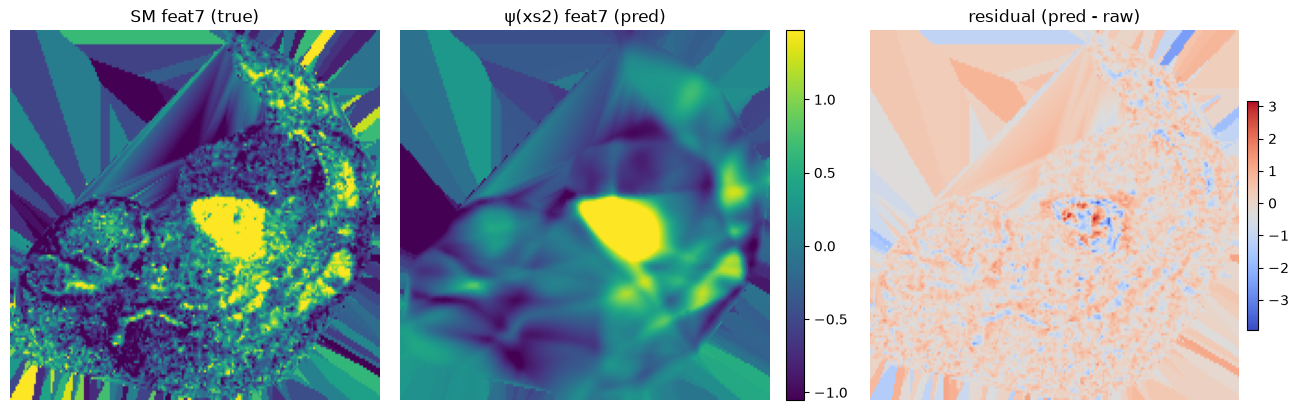

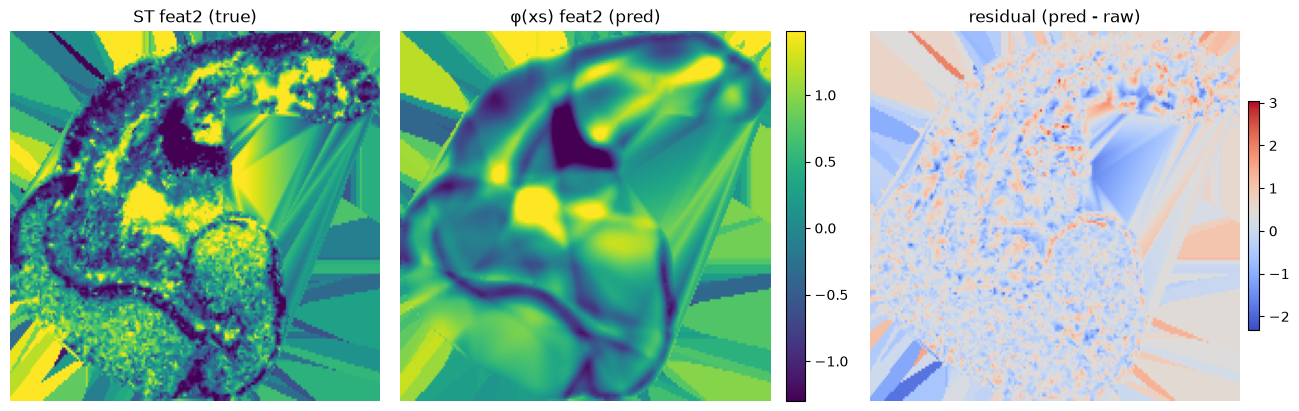

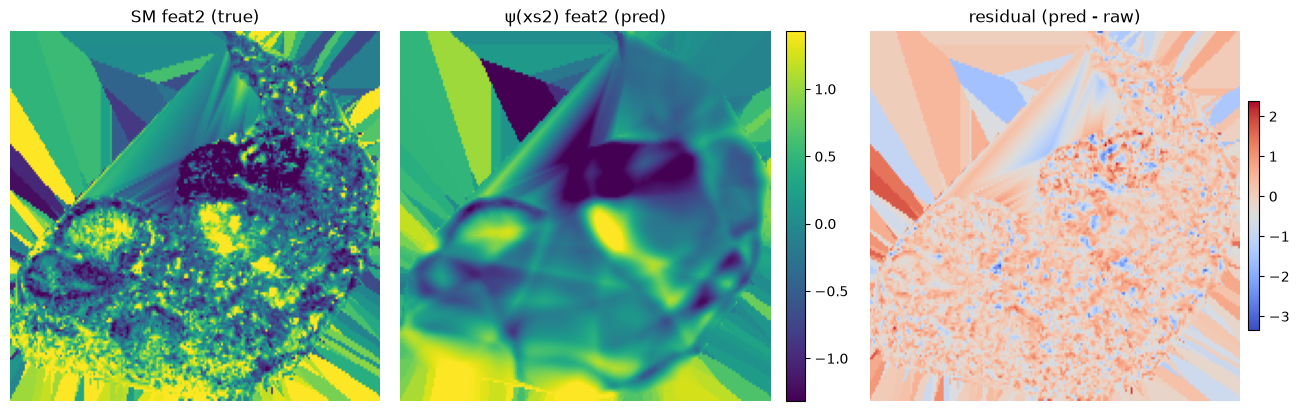

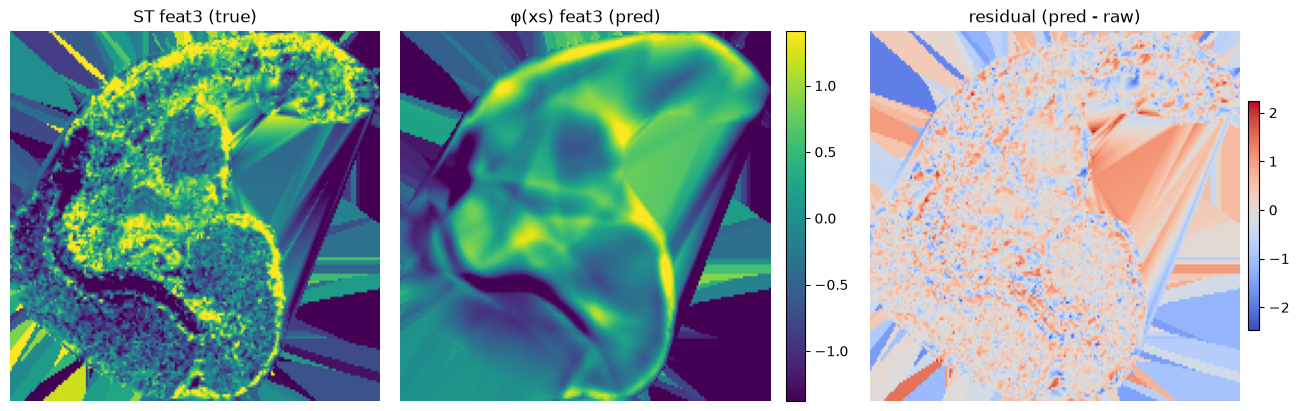

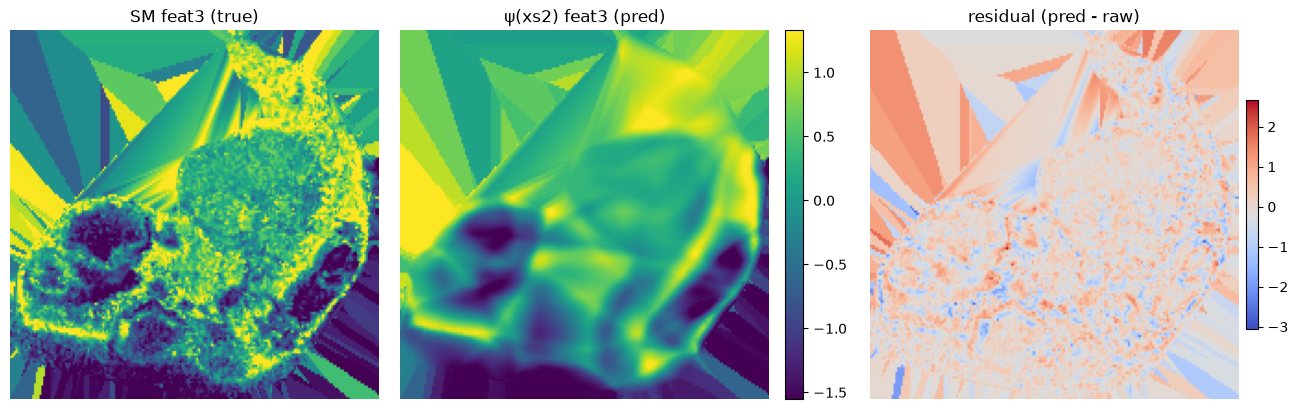

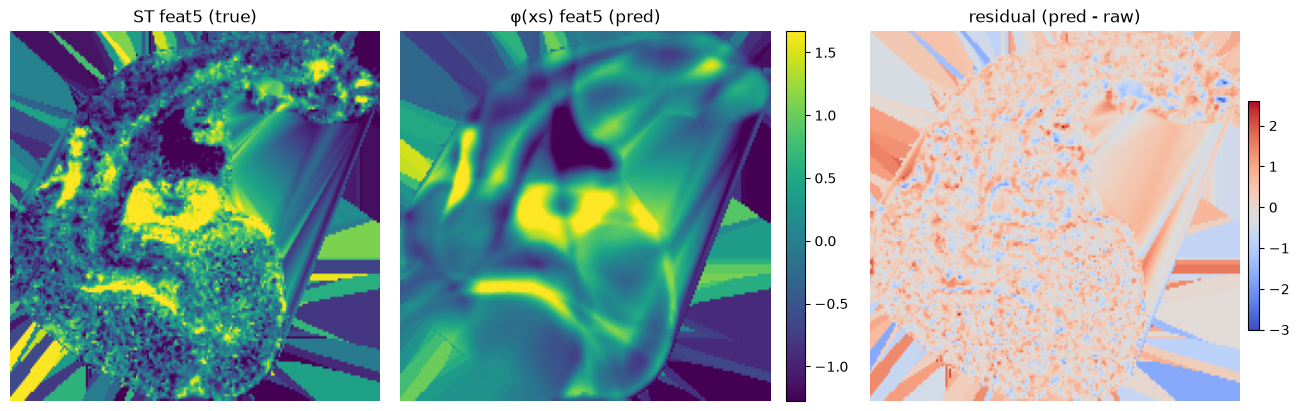

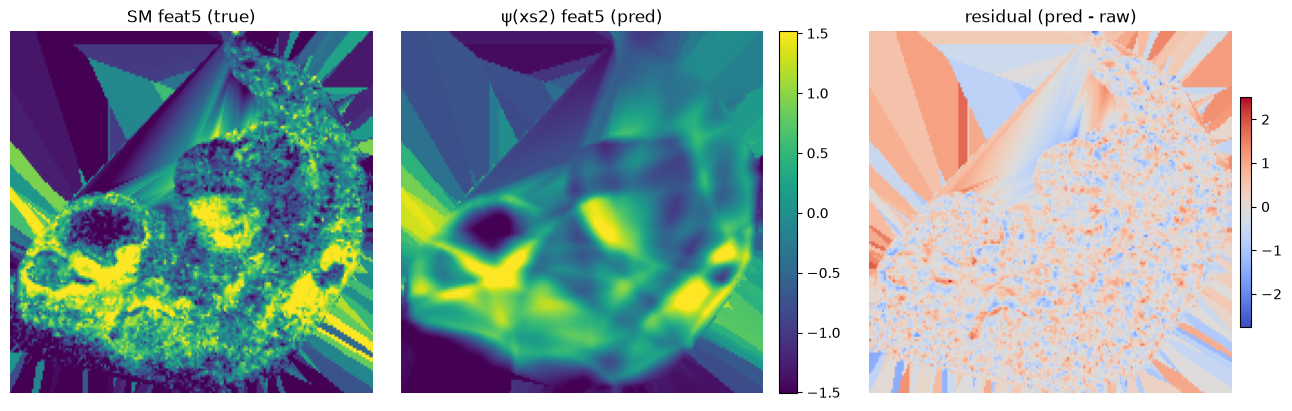

[mgw.core] pullback metrics & geodesics
Rescaling Jacobians by 2164.617100870326.
Rescaling Jacobians by 1628.9588184850354.
[mgw.core] cost matrices: d^2 (cost_p=2)
[mgw.core] solving GW with {'verbose': True, 'inner_maxit': 3000, 'outer_maxit': 3000, 'inner_tol': 1e-07, 'outer_tol': 1e-07, 'epsilon': 0.0001}
[mgw.core] coupling: shape=(14000, 14000), mass=1.000000


In [8]:
out = mgw.mgw_align_core(
        pre,
        widths=PHI_ARC,
        lr=DEFAULT_LR,
        niter=DEFAULT_ITER,
        knn_k=KNN_K,
        geodesic_eps=DEFAULT_EPS,
        save_dir=EXP_PATH, 
        tag=EXP_TAG, 
        verbose=True,
        plot_net=True,
        gw_params = DEFAULT_GW_PARAMS,
        seed=SEED,
        deterministic=True,
        n_restarts=1,
    )

# We can plot the alignment after mapping B into A's frame with a Procrustes fit to the coupling.

The fit allows a reflection (`ensure_rotation=False`), so B is drawn the way the coupling actually places it. Lines join a random subset of A bins to their peak target in B.

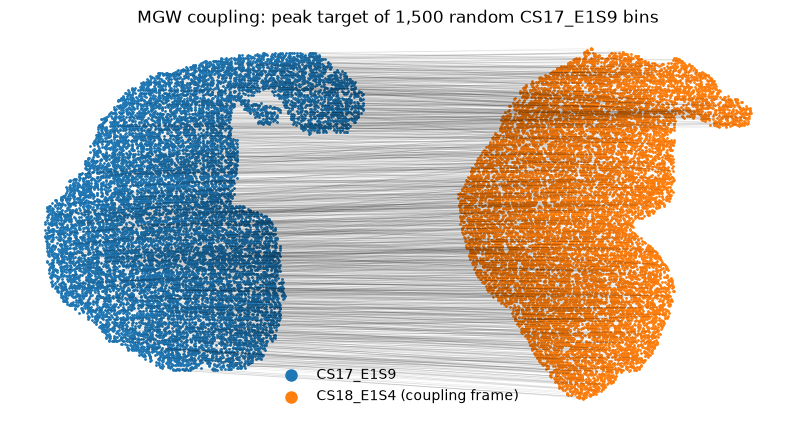

In [9]:
xs = out["xs"]
xs2 = out["xs2"]
P = out["P"]
xt_aligned = plot_coupling_lines(xs, xs2, P, "MGW coupling")

# We can check the orientation of the alignment.

Fit a rigid map from A to the coupling's barycentric image of A in B, once as a rotation and once as a reflection. If the reflection fits clearly better (`det = -1`), the coupling is a mirror image of a rotation.

In [10]:
orientation_report(xs, xs2, P)

orientation det = -1
best rotation    angle  -31°  rms 0.3763
best reflection  mirror axis  +57°  rms 0.0796


# We can also view the alignment as two tilted layers joined by the coupling's peak links.

The bottom layer is drawn with the closest proper rotation. If the orientation check above reports `det = -1`, that rotation does not describe the coupling, and the lines cross over.

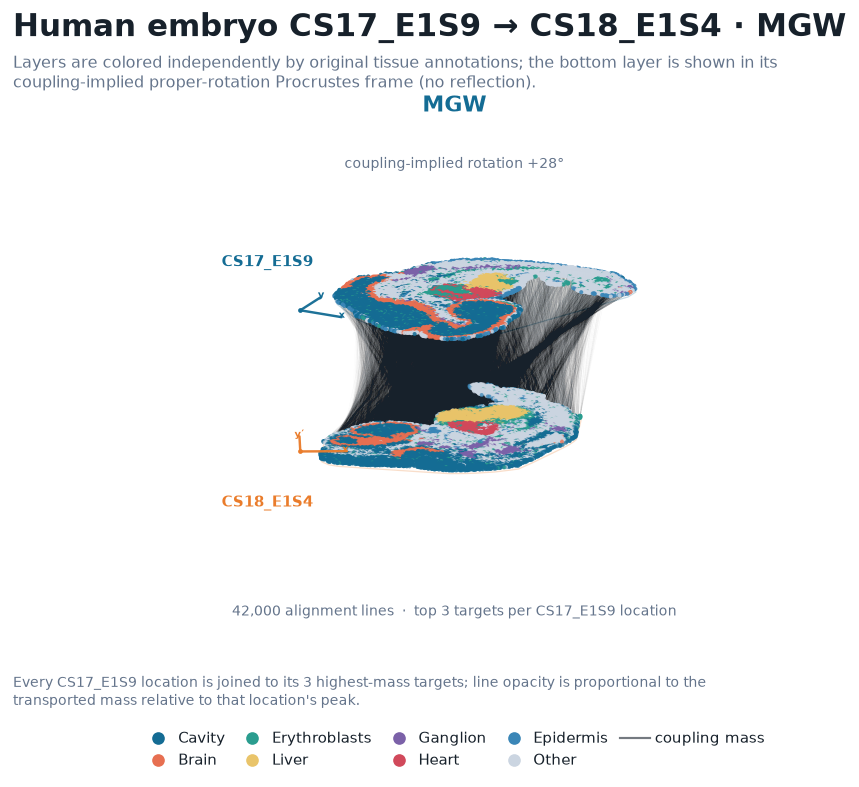

In [11]:
from mgw import align_vis

A_labels = plotting._labels_or_cluster(A, key="celltype")
B_labels = plotting._labels_or_cluster(B, key="celltype")

top, bottom, _ = align_vis.coarsen_to_shared_annotations(A_labels, B_labels, max_classes=7)
_ = align_vis.plot_tilted_alignment(
    A.obsm["spatial"], B.obsm["spatial"], top, bottom, P,
    dataset_title=f"Human embryo {tp1} → {tp2} · MGW", top_name=tp1, bottom_name=tp2,
    label_description="original tissue annotations", k_per_point=3)

# One can also project the annotations through the alignment to find the `mgw` predicted clusters.

B's labels are moved to A through the coupling and compared with A's own labels.

label transfer accuracy CS18_E1S4 → CS17_E1S9: 0.273


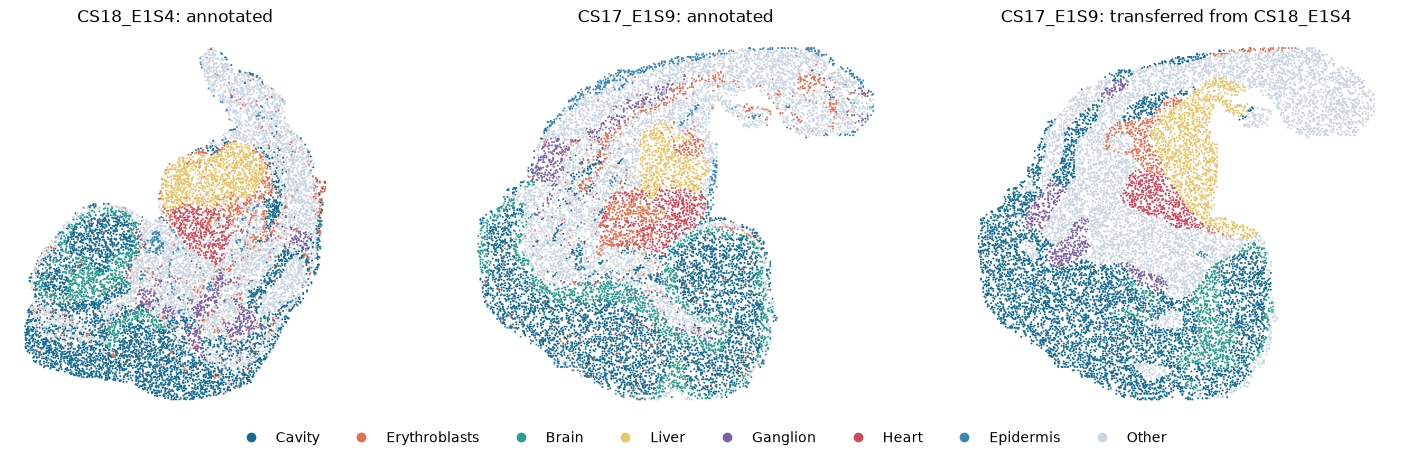

In [12]:
from matplotlib.lines import Line2D

A_pred, A_conf, _ = plotting.project_labels_via_P(P.T, B_labels, direction="A_to_B")
print(f"label transfer accuracy {tp2} → {tp1}: {(A_pred == A_labels).mean():.3f}")

_, _, classes = align_vis.coarsen_to_shared_annotations(A_labels, B_labels, max_classes=7)
palette = dict(zip(classes, align_vis.CATEGORY_COLORS))
palette["Other"] = "#CBD5E1"
coarse = lambda lab: np.where(np.isin(lab, classes), lab, "Other")

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
panels = [(B.obsm["spatial"], B_labels, f"{tp2}: annotated"),
          (A.obsm["spatial"], A_labels, f"{tp1}: annotated"),
          (A.obsm["spatial"], A_pred, f"{tp1}: transferred from {tp2}")]
for a, (xy, lab, title) in zip(ax, panels):
    a.scatter(*xy.T, c=[palette[l] for l in coarse(lab)], s=2, linewidths=0)
    a.set_title(title); a.set_aspect("equal"); a.axis("off")
fig.legend(handles=[Line2D([0], [0], marker="o", ls="", color=palette[c], label=c) for c in palette],
           loc="outside lower center", ncol=len(palette), frameon=False)
plt.show()

# Mirror test: compare the coupling with the best rigid maps.

Rotate A, with and without flipping it, onto B and transfer B's labels by nearest neighbour. This uses the annotations, so it is a diagnostic, not part of MGW. If the best rotation transfers labels much better than the best reflection, and the MGW accuracy is close to the reflection's, the coupling is mirrored.

In [13]:
from scipy.spatial import cKDTree

a_xy = A.obsm["spatial"] - A.obsm["spatial"].mean(0)
b_xy = B.obsm["spatial"] - B.obsm["spatial"].mean(0)
tree = cKDTree(b_xy)

def rigid_accuracy(theta, flip):
    c, s = np.cos(theta), np.sin(theta)
    xy = a_xy * [1, -1] if flip else a_xy
    return (B_labels[tree.query(xy @ np.array([[c, s], [-s, c]]))[1]] == A_labels).mean()

thetas = np.radians(np.arange(0, 360, 5))
for flip, name in [(False, "rotation"), (True, "flip y + rotation")]:
    acc = [rigid_accuracy(t, flip) for t in thetas]
    k = int(np.argmax(acc))
    print(f"best {name:<18} {np.degrees(thetas[k]):3.0f}°  accuracy {acc[k]:.3f}")
print(f"MGW coupling                  accuracy {(A_pred == A_labels).mean():.3f}")

best rotation           310°  accuracy 0.143
best flip y + rotation  110°  accuracy 0.173
MGW coupling                  accuracy 0.273


# Save the coupling for later analysis.

In [14]:
np.save(save_dir / f"P_{tp1}_{tp2}.npy", P)
print("Saved", save_dir / f"P_{tp1}_{tp2}.npy")

Saved /nas/lnt/ga79jin/MGW/data/hesta/alignments/P_CS17_E1S9_CS18_E1S4.npy
